In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid import (
    make_radial_grid,
    cell_centers,
    shell_volumes,
    log_cell_centers,
    log_shell_volumes,
)
from initial_conditions import (
    nfw_dimensionless,
    truncated_nfw_dimensionless,
    enclosed_mass,
    shell_mass,
    hydrostatic_u_from_rho,
)
from residual import hydrostatic_residual, hydrostatic_terms_and_scale
from state import state_from_unknowns
from constants import FLOAT_DTYPE
from jacobian import *

In [2]:
r_inner = 0.0
r_first = 0.001
r_max = 70.0
N_shell = 200

In [3]:
r_edge = make_radial_grid(r_first, r_max, N_shell)
r = cell_centers(r_edge)
V = shell_volumes(r_edge)

In [4]:
ln_r_edge = np.empty(N_shell + 1, dtype=FLOAT_DTYPE)
ln_r_edge[0] = -np.inf if r_inner == 0.0 else np.log(r_inner)
ln_r_edge[1:] = np.log(r_edge[1:])

ln_r = log_cell_centers(ln_r_edge)
ln_V = log_shell_volumes(ln_r_edge)

In [5]:
r_edge.dtype, r.dtype, V.dtype, ln_r.dtype, ln_V.dtype

(dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'))

In [6]:
rho = nfw_dimensionless(r)
dm = shell_mass(rho, V)
M_edge = enclosed_mass(dm)
u = hydrostatic_u_from_rho(r_edge, rho, M_edge, u_outer=0.01)

In [7]:
rho.dtype, dm.dtype, M_edge.dtype, u.dtype

(dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'))

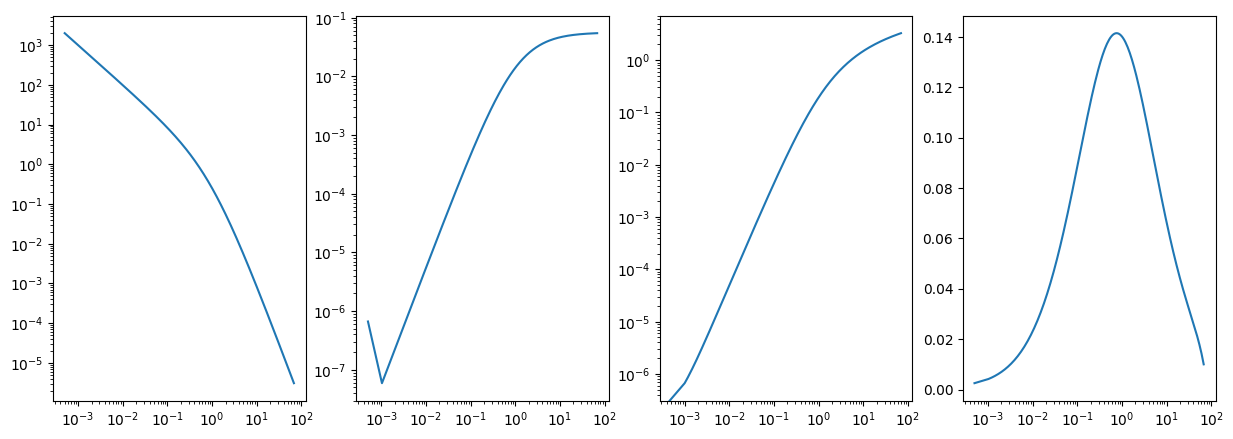

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharex="all")
ax[0].plot(r, rho)
ax[1].plot(r, dm)
ax[2].plot(r_edge, M_edge)
ax[3].plot(r, u)

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")

In [9]:
sigma_over_m = FLOAT_DTYPE(0.3)
C = FLOAT_DTYPE(0.8)
alpha = FLOAT_DTYPE(1.0)

state = state_from_unknowns(ln_r_edge, u, dm, sigma_over_m, C, alpha)
r_edge = state["r_edge"]
ln_r = state["ln_r"]
V = state["V"]
ln_rho = state["ln_rho"]
ln_u = state["ln_u"]
L = state["L"]

In [10]:
F_H, scaled_F_H = hydrostatic_residual(r_edge, ln_r, u, ln_u, ln_rho, M_edge)

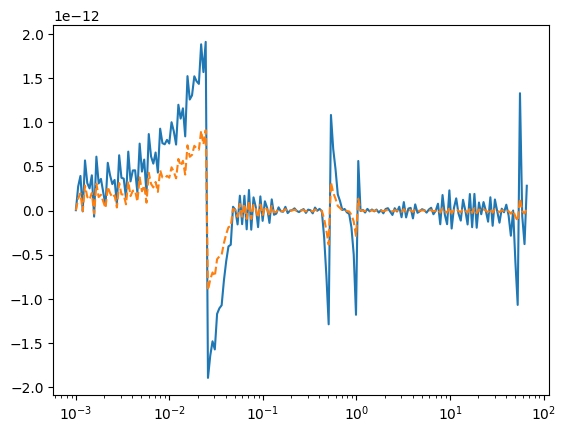

In [11]:
fig, ax = plt.subplots()
ax.plot(r_edge[1:-1], F_H)
ax.plot(r_edge[1:-1], scaled_F_H, ls="--")
ax.set_xscale("log")

In [12]:
rho_slope, u_slope, gravity_slope, hydro_scale = hydrostatic_terms_and_scale(
    r_edge, ln_r, u, ln_u, ln_rho, M_edge
)

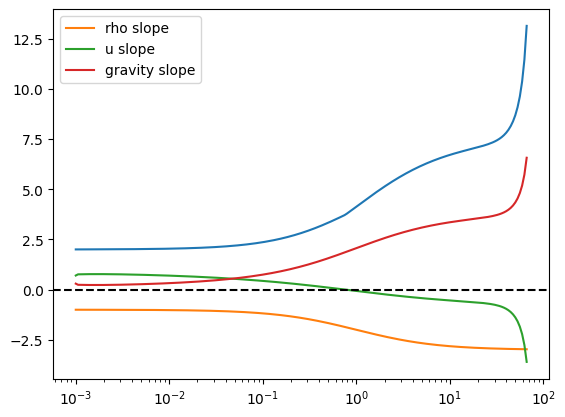

In [13]:
fig, ax = plt.subplots()

ax.plot(r_edge[1:-1], hydro_scale)

ax.plot(r_edge[1:-1], rho_slope, label="rho slope")
ax.plot(r_edge[1:-1], u_slope, label="u slope")

ax.plot(r_edge[1:-1], gravity_slope, label="gravity slope")

ax.axhline(y=0, ls="--", color="black")

ax.legend()
ax.set_xscale("log")

In [14]:
a, b, c = jacobian_hydro_block(ln_r_edge, u, state, M_edge, N_shell)

In [15]:
c.shape

(199, 399)